In [1]:
import os
os.environ['MUJOCO_GL'] = 'egl'

import mujoco

xml = """
<mujoco>
    <worldbody>
        <geom name="red_box" type="box" size=".2 .2 .2" rgba="1 0 0 1"/>
        <geom name="green_sphere" pos=".2 .2 .2" size=".1" rgba="0 1 0 1"/>
    </worldbody>
</mujoco>
"""

In [ ]:
# 물리법칙 적용
model = mujoco.MjModel.from_xml_string(xml)
data = mujoco.MjData(model)

renderer = mujoco.Renderer(model, height=480, width=640)

mujoco.mj_forward(model, data)
renderer.update_scene(data)

frames = renderer.render()

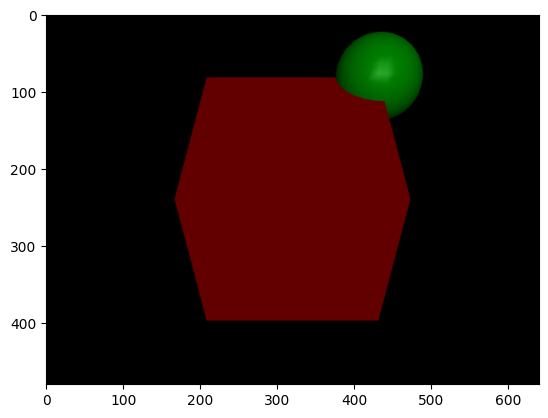

In [3]:
import matplotlib.pyplot as plt

# 화면에 표시
plt.imshow(frames)

In [4]:
# 카메라 각도 변경
model = mujoco.MjModel.from_xml_string(xml)
data = mujoco.MjData(model)

renderer = mujoco.Renderer(model, height=480, width=640)

In [5]:
duration = 5
framerate = 60
frames = []

# MjvCamera
cam = mujoco.MjvCamera()
cam.lookat = [0.1, 0.1, 0.1]
cam.distance = 2.0
cam.elevation = -20

In [6]:
num_frames = duration * framerate
for i in range(num_frames):
    cam.azimuth = 360 * i / num_frames
    mujoco.mj_forward(model, data)
    renderer.update_scene(data, camera=cam)
    pixels = renderer.render()
    frames.append(pixels)

In [7]:
# 각 이미지를 영상처럼 이어뿌리기
from IPython.display import Image, clear_output, display
import cv2

def display_image(frame):
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    _, buffer = cv2.imencode('.jpg', frame)
    clear_output(wait=True)
    display(Image(data=buffer, width=500))

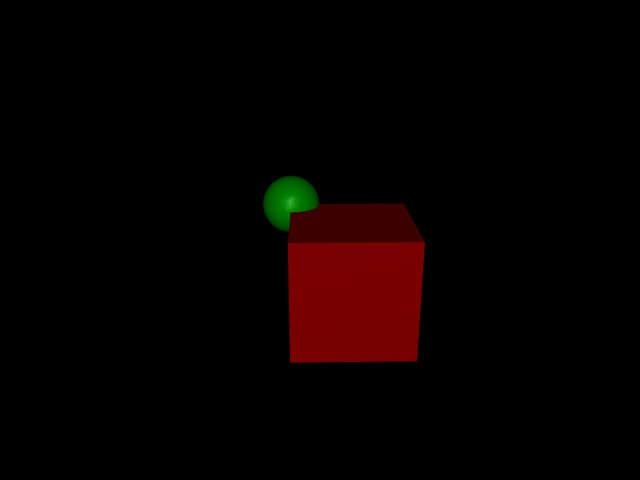

In [8]:
import time
for frame in frames:
    display_image(frame)
    time.sleep(1.0 / framerate)